In [19]:
import numpy as np
import matplotlib.pyplot as plt

from tqdm import tqdm

import matplotlib.cm as cm
import colormaps as cmaps
import matplotlib.colors as colors
from labellines import labelLines
from matplotlib.cm import brg, ScalarMappable
from matplotlib.colors import (
    LogNorm,
    TwoSlopeNorm,
    LinearSegmentedColormap,
    Normalize,
    ListedColormap,
)
from matplotlib.lines import Line2D

import jax
import jax.numpy as jnp
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

# plt.rcParams.update(
# {"text.usetex": True, "font.family": "Helvetica", "font.size": 8}
# )

plt.rcParams.update(
    {
        "text.usetex": False,
        "font.family": "sans-serif",
        "font.sans-serif": ["Calibri"],
        "font.size": 8,
        "mathtext.fontset": "cm",
    }
)

gnuplot_barve = cm.gnuplot2_r(np.linspace(0.3, 1, 10))
gnuplot_custom = LinearSegmentedColormap.from_list("gnuplot_custom", gnuplot_barve)

brg_barve = cmaps.guppy(np.linspace(0, 1, 10))
bgr_custom = LinearSegmentedColormap.from_list("bgr_custom", brg_barve)

YlGn_barve = cm.YlGn(np.linspace(0, 0.8, 10))
ylgn_custom = LinearSegmentedColormap.from_list("ylgn_custom", YlGn_barve)

markers = ["o", "D", "^", "x", "v", "<", ">", "p", "*", "X"]

set1_list = [
    "#e41a1c",
    "#377eb8",
    "#4daf4a",
    "#984ea3",
    "#ff7f00",
    "#f781bf",
    "#999999",
    "#a65628",
]
bold_list = [
    "#7f3c8d",
    "#11a579",
    "#3969ac",
    "#e73f74",
    "#f2b701",
    "#80ba5a",
    "#e68310",
    "#008695",
    "#cf1c90",
    "#f97b72",
    "#a5aa99",
]


W = 5.0
from utils import newfig, fd

import utils as ut
import ei_open_loop as eol
import ei_unified as eu
import ei_jax as ej

OUT = "/home/kzeleznikar/IJS-F1/Koda/EI_baths/"
from matplotlib_inline.backend_inline import set_matplotlib_formats

set_matplotlib_formats("png", dpi=300)

import yaml

In [2]:
from pathlib import Path

import numpy as np
import yaml


cfg_path = Path(
    "/home/kzeleznikar/IJS-F1/Koda/EI_baths/config/config_test.yaml"
)

with cfg_path.open("r") as f:
    cfg = yaml.safe_load(f)

md = cfg["model"]
eq = cfg["equilibrium"]
sc = cfg["scan"]
op = cfg["open_system"]

nk = md["nk"]
bp = md["band"]["pars"]

bd = eu.tb_2d(nk["scan"], **bp)
bd_ref = eu.tb_2d(nk["reference"], **bp)

p = eu.MFPars(**md["mean_field"])

In [3]:
s0 = eu.solve_eq(bd_ref, p, **eq["initial"], **eq["solve"])

d0 = abs(s0.d)
mu0 = s0.mu

# za normalizacijo
tc = eu.critical_temperature(bd_ref, p, **eq["critical"])

print("Delta_0 =", d0)
print("T_c     =", tc)
print("mu0     =", mu0)

kriticna temp bisekcija:   0%|          | 0/100 [00:00<?, ?it/s]

Delta_0 = 1.3438528043955609
T_c     = 0.6195541953906416
mu0     = 2.452325280461837


In [4]:
tg = sc["temperature"]

tn = np.linspace( tg["min_ratio"], tg["max_ratio"], tg["nt"])

t1a = tn * tc
t2a = tn * tc
nt = tg["nt"]

In [5]:
mua = np.empty(nt)

de = s0.d
me = s0.m

for q in tqdm(range(nt), desc="eq. mu_B refs"):
    sq = eu.solve_eq(bd, p, t=t1a[q], d=1.0, m=0.0, **eq["solve"])

    mua[q] = sq.mu

    de = sq.d
    me = sq.m

print(mua)
mu_B = np.mean(mua)

eq. mu_B refs: 100%|██████████| 10/10 [00:08<00:00,  1.20it/s]

[1.80568002 1.40957613 1.52249594 1.6088433  1.67155412 1.77607218
 1.90965081 2.02485252 2.12111442 2.19906061]


In [6]:
bc = op["bath"]

rf = getattr(ej, bc["rate"])

bpars = dict(bc["pars"])
bpars["rate"] = rf

In [7]:
da = np.full((nt, nt), np.nan)
ma = np.full((nt, nt), np.nan)
er = np.full((nt, nt), np.nan)
it = np.zeros((nt, nt), dtype=int)
ok = np.zeros((nt, nt), dtype=bool)


for j in tqdm(range(nt), desc="T2"):
    t2 = t2a[j]
    se = eu.solve_eq(bd, p, t=t2,
        d=max(abs(de), 1.0e-6),
        m=me,
        mix=(0.15, 0.15),
        tol=1.0e-9,
        nmax=20000,
        chk=20,
        prog=False,
    )

    n = se.n.copy()
    d = se.d
    m = se.m

    for i in tqdm(
        range(j, nt),
        desc="T1",
        leave=False,
    ):
        t1 = t1a[i]
        bs = (ej.gam_db(t=t1, name="bath 1", **bpars),
              ej.gam_db(t=t2, name="bath 2", **bpars))

        so = ej.solve_open(bd, p, n, bs, d=d, m=m, **op["solve"])

        ds = 0.1 * d0

        da[j, i] = abs(so.d)
        ma[j, i] = so.m
        er[j, i] = so.err
        it[j, i] = so.it
        ok[j, i] = so.ok

        #update
        n = so.n.copy()
        d = max(abs(so.d), ds)
        m = so.m

        da[i, j] = da[j, i]
        ma[i, j] = ma[j, i]
        er[i, j] = er[j, i]
        it[i, j] = it[j, i]
        ok[i, j] = ok[j, i]

T2: 100%|██████████| 10/10 [00:08<00:00,  1.12it/s]


In [8]:
def plot_phase_diag(da, d0, tn, config=None, OUT=None, name="phase_diag", save=False, overwrite=False):
    z = da / d0

    h=0.85
    cm = cmaps.lipari

    fig, ax = plt.subplots(figsize=(3.47412, h * 3.47412))

    im = ax.pcolormesh(tn, tn, z, shading="auto", cmap=cm, vmin=0.0)
    im.set_edgecolor("face")

    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label(r"$\Delta/\Delta_0$", rotation=90, labelpad=5)
    
    #probe points
    r = np.array([x**2 for x in np.arange(1, 3, 0.2)])
    ax.scatter(0.7 * np.sqrt(r), 0.7 / np.sqrt(r), color="green")

    ax.set_xlabel(r"$T_1/T_c$")
    ax.set_ylabel(r"$T_2/T_c$")
    ax.set_xlim(tn.min(), tn.max())
    ax.set_ylim(tn.min(), tn.max())

    plt.tight_layout()

    if save:
        if OUT is None:
            raise ValueError("OUT must be provided when save=True")

        if config is None:
            raise ValueError("config must be provided when save=True")

        OUT = Path(OUT)
        OUT.mkdir(parents=True, exist_ok=True)

        plot_file = OUT / f"{name}.pdf"
        pars_file = OUT / f"{name}.yaml"

        if not overwrite and (plot_file.exists() or pars_file.exists()):
            raise FileExistsError(f"{name} already exists in {OUT}")

        meta = {
            "figure": plot_file.name,
            "simulation": config
        }

        txt = yaml.safe_dump(meta, sort_keys=False)
        fig.savefig(plot_file, bbox_inches="tight")
        pars_file.write_text(txt, encoding="utf-8")

        print("Saved:", plot_file)
        print("Saved:", pars_file)

        plt.show()

findfont: Failed to find font weight normal, now using 300.
findfont: Failed to find font weight normal, now using 300.


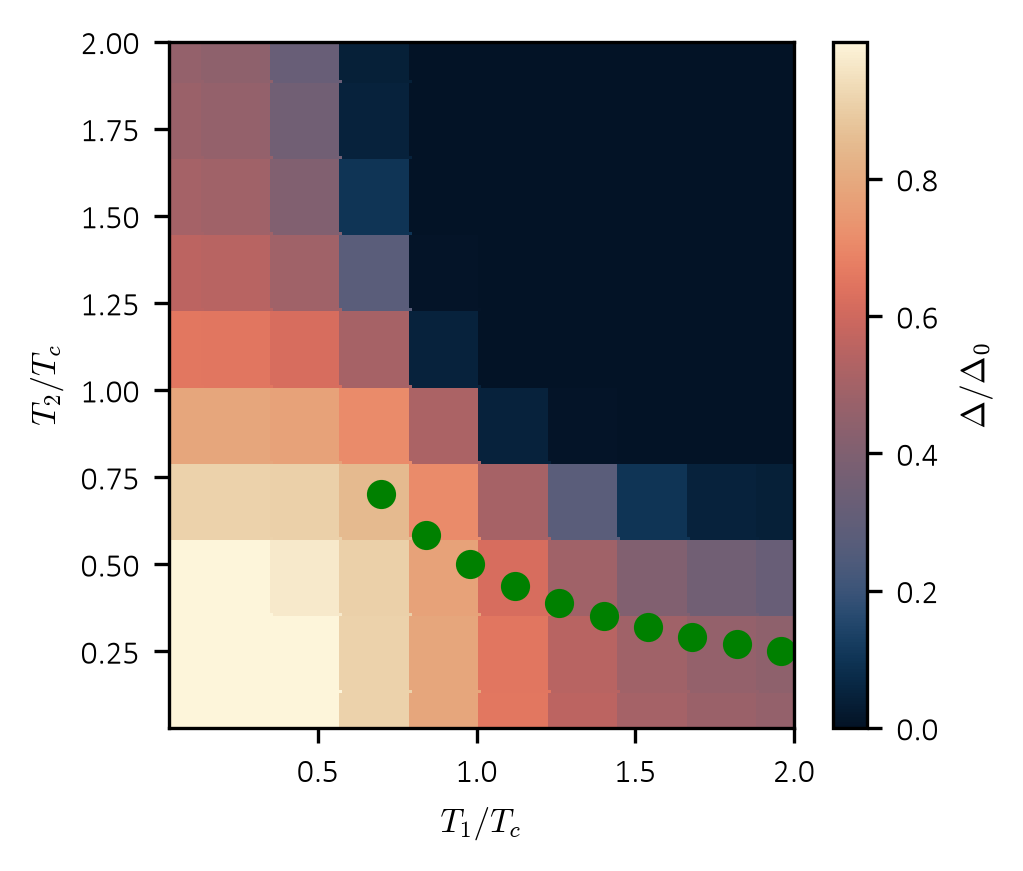

In [9]:
plot_phase_diag(da, d0, tn, config = cfg, OUT=OUT, name="phase_diag_test", save=False)

In [10]:
# import json
# from pathlib import Path
# from datetime import datetime, timezone

# from scipy.interpolate import RegularGridInterpolator


# def point_report(
#     x1,
#     x2,
#     tc0,
#     folder=None,
#     out=None,
#     nk=100,
#     gap=1.0,
#     ta=1.0,
#     tb=-0.3,
#     vv=5.0,
#     nf=1.0,
#     uh=None,
#     kap=(0.3, 0.6, 0.3),
#     wc=np.inf,
#     dseed=None,
#     mseed=None,
#     dt=0.8,
#     td=0.3,
#     tm=0.3,
#     tol=1.0e-4,
#     nmax=20000,
#     chk=20,
#     mode="dense",
#     block=512,
#     ns=240,
#     show=True,
# ):
#     if out is None:
#         out = OUT

#     if folder is None:
#         a = f"{x1:.3f}".replace(".", "p")
#         b = f"{x2:.3f}".replace(".", "p")
#         folder = f"point_t1_{a}_t2_{b}"

#     root = Path(out) / folder
#     pdir = root / "plots"

#     root.mkdir(parents=True, exist_ok=True)
#     pdir.mkdir(parents=True, exist_ok=True)

#     bd = eu.tb_2d(
#         nk=nk,
#         gap=gap,
#         ta=ta,
#         tb=tb,
#     )

#     p = eu.MFPars(
#         v=vv,
#         n=nf,
#         uh=uh,
#     )

#     s0 = eu.solve_eq(
#         bd,
#         p,
#         t=0.0,
#         d=1.0,
#         m=0.0,
#         mix=(0.15, 0.15),
#         tol=1.0e-10,
#         nmax=20000,
#         chk=20,
#         prog=True,
#     )

#     d0 = abs(s0.d)
#     mu0 = s0.mu

#     t1 = x1 * tc0
#     t2 = x2 * tc0
#     ts = min(t1, t2)

#     se = eu.solve_eq(
#         bd,
#         p,
#         t=ts,
#         d=max(d0, 1.0e-6),
#         m=s0.m,
#         mix=(0.15, 0.15),
#         tol=1.0e-9,
#         nmax=20000,
#         chk=20,
#         prog=True,
#     )

#     if dseed is None:
#         di = max(abs(se.d), d0)
#     else:
#         di = float(dseed)

#     if mseed is None:
#         mi = float(se.m)
#     else:
#         mi = float(mseed)

#     bs = (
#         ej.gam_db(
#             t1,
#             kap=kap,
#             wc=wc,
#             mu=mu_B,
#             name="bath 1",
#             rate=ej.rate_product,
#         ),
#         ej.gam_db(
#             t2,
#             kap=kap,
#             wc=wc,
#             mu=mu_B,
#             name="bath 2",
#             rate=ej.rate_product,
#         ),
#     )

#     so = ej.solve_open(
#         bd,
#         p,
#         se.n.copy(),
#         bs,
#         d=di,
#         m=mi,
#         dt=dt,
#         td=td,
#         tm=tm,
#         tol=tol,
#         nmax=nmax,
#         chk=chk,
#         prog=True,
#         mode=mode,
#         block=block,
#     )

#     st = ej.mf_state(
#         bd,
#         p,
#         d=so.d,
#         m=so.m,
#     )

#     nq = np.asarray(so.n)
#     eq = np.asarray(st.e)

#     ug = np.asarray(st.u).reshape(nk, nk)
#     vg = np.asarray(st.v).reshape(nk, nk)

#     ag = nq[0].reshape(nk, nk)
#     bg = nq[1].reshape(nk, nk)

#     oa, ob = ej.band_occ(
#         st,
#         so.n,
#     )

#     oa = np.asarray(oa).reshape(nk, nk)
#     ob = np.asarray(ob).reshape(nk, nk)

#     epg = eq[0].reshape(nk, nk)
#     emg = eq[1].reshape(nk, nk)

#     hag = np.asarray(st.eah).reshape(nk, nk)
#     hbg = np.asarray(st.ebh).reshape(nk, nk)

#     eag = np.asarray(bd.ea).reshape(nk, nk)
#     ebg = np.asarray(bd.eb).reshape(nk, nk)

#     ka = np.linspace(
#         -np.pi,
#         np.pi,
#         nk,
#         endpoint=False,
#     )

#     kx, ky = np.meshgrid(
#         ka,
#         ka,
#         indexing="ij",
#     )

#     ke = np.concatenate(
#         (
#             ka,
#             np.array([np.pi]),
#         )
#     )

#     q = np.linspace(
#         0.0,
#         1.0,
#         ns,
#         endpoint=False,
#     )

#     p1 = np.column_stack(
#         (
#             np.pi * q,
#             np.zeros_like(q),
#         )
#     )

#     p2 = np.column_stack(
#         (
#             np.full_like(q, np.pi),
#             np.pi * q,
#         )
#     )

#     p3 = np.column_stack(
#         (
#             np.pi * (1.0 - q),
#             np.pi * (1.0 - q),
#         )
#     )

#     kp = np.vstack(
#         (
#             p1,
#             p2,
#             p3,
#             np.array([[0.0, 0.0]]),
#         )
#     )

#     dk = np.diff(kp, axis=0)
#     dl = np.sqrt(np.sum(dk * dk, axis=1))

#     sp = np.concatenate(
#         (
#             np.array([0.0]),
#             np.cumsum(dl),
#         )
#     )

#     ix = np.array(
#         [
#             0,
#             ns,
#             2 * ns,
#             3 * ns,
#         ]
#     )

#     sx = sp[ix]

#     def per(z):
#         ze = np.pad(
#             z,
#             ((0, 1), (0, 1)),
#             mode="wrap",
#         )

#         fn = RegularGridInterpolator(
#             (ke, ke),
#             ze,
#             method="linear",
#             bounds_error=False,
#         )

#         return fn(kp)

#     epp = per(epg)
#     emp = per(emg)

#     hap = per(hag)
#     hbp = per(hbg)

#     ap = per(ag)
#     bp = per(bg)

#     oap = per(oa)
#     obp = per(ob)

#     up = per(ug)
#     vp = per(vg)

#     xl = [
#         r"$\Gamma$",
#         r"$X$",
#         r"$M$",
#         r"$\Gamma$",
#     ]

#     es = abs(ta)

#     def save_fig(fig, name):
#         fig.savefig(
#             pdir / f"{name}.pdf",
#             bbox_inches="tight",
#         )

#         if show:
#             plt.show()

#         plt.close(fig)

#     def add_path_lines(ax):
#         ax.axvline(
#             sx[1],
#             color="0.5",
#             lw=0.7,
#             alpha=0.5,
#         )

#         ax.axvline(
#             sx[2],
#             color="0.5",
#             lw=0.7,
#             alpha=0.5,
#         )

#         ax.set_xticks(sx, xl)
#         ax.set_xlim(sp[0], sp[-1])

#     def map_pair(
#         z0,
#         z1,
#         l0,
#         l1,
#         name,
#         vmin,
#         vmax,
#     ):
#         h = 1.75

#         fig, ax = plt.subplots(
#             2,
#             1,
#             figsize=(3.47412, h * 3.47412),
#         )

#         zz = (z0, z1)
#         ll = (l0, l1)

#         for j in tqdm(
#             range(2),
#             desc=f"{name} maps",
#             leave=False,
#         ):
#             im = ax[j].pcolormesh(
#                 kx,
#                 ky,
#                 zz[j],
#                 shading="auto",
#                 cmap=cmaps.bubblegum,
#                 vmin=vmin,
#                 vmax=vmax,
#             )

#             im.set_edgecolor("face")

#             cbar = fig.colorbar(
#                 im,
#                 ax=ax[j],
#             )

#             cbar.set_label(
#                 ll[j],
#                 rotation=90,
#                 labelpad=5,
#             )

#             ax[j].text(
#                 0.04,
#                 0.94,
#                 ll[j],
#                 transform=ax[j].transAxes,
#                 ha="left",
#                 va="top",
#             )

#             ax[j].set_xlabel(r"$k_x$")
#             ax[j].set_ylabel(r"$k_y$")

#             ax[j].set_xlim(
#                 ka[0],
#                 ka[-1],
#             )

#             ax[j].set_ylim(
#                 ka[0],
#                 ka[-1],
#             )

#             ax[j].set_aspect("equal")

#         plt.tight_layout()
#         save_fig(fig, name)

#     def path_pair(
#         z0,
#         z1,
#         l0,
#         l1,
#         yl,
#         name,
#     ):
#         h = 0.65

#         fig, ax = plt.subplots(figsize=(3.47412, h * 3.47412))

#         ax.plot(
#             sp,
#             z0,
#             color=set1_list[0],
#             lw=1.5,
#             label=l0,
#         )

#         ax.plot(
#             sp,
#             z1,
#             color=set1_list[1],
#             lw=1.5,
#             label=l1,
#         )

#         add_path_lines(ax)

#         ax.set_xlabel(r"$\mathbf{k}$")
#         ax.set_ylabel(yl)
#         ax.grid(alpha=0.3)

#         ax.legend()

#         plt.tight_layout()
#         save_fig(fig, name)

#     h = 1.25

#     fig, ax = plt.subplots(
#         2,
#         1,
#         figsize=(3.47412, h * 3.47412),
#         sharex=True,
#     )

#     ax[0].plot(
#         sp,
#         epp / es,
#         color=set1_list[0],
#         lw=1.5,
#         label=r"$E_{\alpha\mathbf{k}}$",
#     )

#     ax[0].plot(
#         sp,
#         emp / es,
#         color=set1_list[1],
#         lw=1.5,
#         label=r"$E_{\beta\mathbf{k}}$",
#     )

#     ax[0].plot(
#         sp,
#         hap / es,
#         color=set1_list[2],
#         lw=1.0,
#         ls="--",
#         label=r"$\epsilon^H_{a\mathbf{k}}$",
#     )

#     ax[0].plot(
#         sp,
#         hbp / es,
#         color=set1_list[3],
#         lw=1.0,
#         ls="--",
#         label=r"$\epsilon^H_{b\mathbf{k}}$",
#     )

#     ax[0].axvline(
#         sx[1],
#         color="0.5",
#         lw=0.7,
#         alpha=0.5,
#     )

#     ax[0].axvline(
#         sx[2],
#         color="0.5",
#         lw=0.7,
#         alpha=0.5,
#     )

#     ax[0].set_xlim(sp[0], sp[-1])
#     ax[0].set_ylabel(r"$E/|t_a|$")
#     ax[0].grid(alpha=0.3)

#     ax[0].text(
#         0.03,
#         0.05,
#         (rf"$T_1={x1:.3f}T_c$" "\n" rf"$T_2={x2:.3f}T_c$"),
#         transform=ax[0].transAxes,
#         ha="left",
#         va="bottom",
#     )

#     ax[0].legend()

#     ax[1].plot(
#         sp,
#         up,
#         color=set1_list[0],
#         lw=1.5,
#         label=r"$u_{\mathbf{k}}$",
#     )

#     ax[1].plot(
#         sp,
#         vp,
#         color=set1_list[1],
#         lw=1.5,
#         label=r"$v_{\mathbf{k}}$",
#     )

#     add_path_lines(ax[1])

#     ax[1].set_xlabel(r"$\mathbf{k}$")
#     ax[1].set_ylabel(r"$u_{\mathbf{k}},v_{\mathbf{k}}$")
#     ax[1].grid(alpha=0.3)
#     ax[1].legend()

#     plt.tight_layout()
#     save_fig(
#         fig,
#         "dispersion_uv_path",
#     )

#     map_pair(
#         ag,
#         bg,
#         r"$n_{\alpha\mathbf{k}}$",
#         r"$n_{\beta\mathbf{k}}$",
#         "occ_qp_maps",
#         0.0,
#         1.0,
#     )

#     path_pair(
#         ap,
#         bp,
#         r"$n_{\alpha\mathbf{k}}$",
#         r"$n_{\beta\mathbf{k}}$",
#         r"$n_{\lambda\mathbf{k}}$",
#         "occ_qp_path",
#     )

#     map_pair(
#         oa,
#         ob,
#         r"$n_{a\mathbf{k}}$",
#         r"$n_{b\mathbf{k}}$",
#         "occ_ab_maps",
#         0.0,
#         1.0,
#     )

#     path_pair(
#         oap,
#         obp,
#         r"$n_{a\mathbf{k}}$",
#         r"$n_{b\mathbf{k}}$",
#         r"$n_{r\mathbf{k}}$",
#         "occ_ab_path",
#     )

#     uv0 = min(
#         0.0,
#         float(np.min(ug)),
#         float(np.min(vg)),
#     )

#     uv1 = max(
#         1.0,
#         float(np.max(ug)),
#         float(np.max(vg)),
#     )

#     map_pair(
#         ug,
#         vg,
#         r"$u_{\mathbf{k}}$",
#         r"$v_{\mathbf{k}}$",
#         "uv_maps",
#         uv0,
#         uv1,
#     )

#     data_file = root / "diagnostics.npz"

#     np.savez_compressed(
#         data_file,
#         kx=kx,
#         ky=ky,
#         w=np.asarray(bd.w),
#         ea_bare=eag,
#         eb_bare=ebg,
#         ea_hartree=hag,
#         eb_hartree=hbg,
#         e_alpha=epg,
#         e_beta=emg,
#         n_alpha=ag,
#         n_beta=bg,
#         n_a=oa,
#         n_b=ob,
#         u=ug,
#         v=vg,
#         path_s=sp,
#         path_kx=kp[:, 0],
#         path_ky=kp[:, 1],
#         path_e_alpha=epp,
#         path_e_beta=emp,
#         path_ea_hartree=hap,
#         path_eb_hartree=hbp,
#         path_n_alpha=ap,
#         path_n_beta=bp,
#         path_n_a=oap,
#         path_n_b=obp,
#         path_u=up,
#         path_v=vp,
#     )

#     fill = np.sum(np.asarray(bd.w) * np.sum(nq, axis=0))

#     wc_json = "inf" if np.isinf(wc) else float(wc)

#     relax_time = getattr(
#         so,
#         "t",
#         None,
#     )

#     if relax_time is not None:
#         relax_time = float(relax_time)

#     cfg = {
#         "created_utc": datetime.now(timezone.utc).isoformat(),
#         "point": {
#             "t1_over_tc": float(x1),
#             "t2_over_tc": float(x2),
#             "t1": float(t1),
#             "t2": float(t2),
#             "tc_reference": float(tc0),
#         },
#         "grid": {
#             "nk": int(nk),
#             "n_points": int(bd.size),
#             "path_points_per_segment": int(ns),
#             "path": "Gamma-X-M-Gamma",
#         },
#         "bands": {
#             "gap": float(gap),
#             "ta": float(ta),
#             "tb": float(tb),
#         },
#         "mean_field": {
#             "v": float(vv),
#             "filling": float(nf),
#             "uh": (None if uh is None else float(uh)),
#         },
#         "bath": {
#             "rate": "ej.rate_db",
#             "kap_aa": float(kap[0]),
#             "kap_ab": float(kap[1]),
#             "kap_bb": float(kap[2]),
#             "wc": wc_json,
#             "mu": 0.0,
#             "orbital": None,
#         },
#         "solver": {
#             "dt": float(dt),
#             "td": float(td),
#             "tm": float(tm),
#             "tol": float(tol),
#             "nmax": int(nmax),
#             "chk": int(chk),
#             "mode": str(mode),
#             "block": int(block),
#         },
#         "seed": {
#             "equilibrium_temperature": float(ts),
#             "equilibrium_t_over_tc": float(ts / tc0),
#             "equilibrium_d": float(se.d),
#             "equilibrium_m": float(se.m),
#             "equilibrium_mu": float(se.mu),
#             "d_used": float(di),
#             "m_used": float(mi),
#         },
#         "fine_reference": {
#             "delta_0": float(d0),
#             "mu_0": float(mu0),
#         },
#         "result": {
#             "ok": bool(so.ok),
#             "iterations": int(so.it),
#             "error": float(so.err),
#             "relax_time": relax_time,
#             "d": float(so.d),
#             "abs_d": float(abs(so.d)),
#             "abs_d_over_delta_0": float(abs(so.d) / d0),
#             "m": float(so.m),
#             "filling": float(fill),
#         },
#         # "software": {
#         #     "numpy": np.__version__,
#         #     "jax": jax.__version__,
#         #     "ei_unified": str(getattr(eu, "__file__", "")),
#         #     "ei_jax": str(getattr(ej, "__file__", "")),
#         # },
#         # "files": {
#         #     "data": "diagnostics.npz",
#         #     "plot_directory": "plots",
#         #     "plots": [
#         #         "dispersion_uv_path",
#         #         "occ_qp_maps",
#         #         "occ_qp_path",
#         #         "occ_ab_maps",
#         #         "occ_ab_path",
#         #         "uv_maps",
#         #     ],
#         # },
#     }

#     json_file = root / "params.json"

#     with json_file.open(
#         "w",
#         encoding="utf-8",
#     ) as f:
#         json.dump(
#             cfg,
#             f,
#             indent=2,
#             allow_nan=False,
#         )

#     print("Saved to:", root)
#     print("Converged:", so.ok)
#     print("Residual:", so.err)
#     print("Delta / Delta_0:", abs(so.d) / d0)
#     print("Filling:", fill)

#     return {
#         "bd": bd,
#         "p": p,
#         "sol": so,
#         "state": st,
#         "config": cfg,
#         "root": root,
#         "plots": pdir,
#         "data": data_file,
#         "json": json_file,
#     }

In [11]:
# x1 = 3.0
# x2 = 0.05

# i0 = int(
#     np.argmin(np.abs(tn - x1))
# )

# j0 = int(
#     np.argmin(np.abs(tn - x2))
# )

# res = point_report(
#     x1=x1,
#     x2=x2,
#     tc0=tc,
#     folder="b3_t1_3p00_t2_0p05",
#     out=OUT,
#     nk=100,
#     gap=1.0,
#     ta=1.0,
#     tb=-0.3,
#     vv=5.0,
#     nf=1.0,
#     uh=None,
#     kap=(0.3, 0.6, 0.3),
#     wc=np.inf,
#     dseed=max(
#         float(da[j0, i0]),
#         d0,
#     ),
#     mseed=float(ma[j0, i0]),
#     dt=0.8,
#     td=0.3,
#     tm=0.3,
#     tol=1.0e-4,
#     nmax=20000,
#     chk=20,
#     ns=240,
#     show=True,
# )

In [48]:
rs = cfg["ratio_sweep"]

x0 = rs["x0"]
r = np.arange(rs["r_min"], rs["r_max"], rs["r_step"]) ** 2
x1a = x0 * np.sqrt(r)
x2a = x0 / np.sqrt(r)

t0 = x0 * tc

band = getattr(eu, md["band"]["name"])
bd_dense = band(md["nk"]["reference"], **md["band"]["pars"])
p = eu.MFPars(**md["mean_field"])

se = eu.solve_eq(bd_dense, p, t=t0, d=max(abs(s0.d), 1.0e-4), m=s0.m, **eq["solve"])

nk1 = int(round(np.sqrt(se.n.shape[1])))

c = nk1 // 2
q = np.arange(c + 1)

i1 = c - q
j1 = np.full_like(q, c)

i2 = np.zeros(c, dtype=int)
j2 = c - np.arange(1, c + 1)

i3 = np.arange(1, c + 1)
j3 = np.arange(1, c + 1)

ii = np.concatenate((i1, i2, i3))
jj = np.concatenate((j1, j2, j3))

s1 = np.linspace(0.0, np.pi, c + 1)
s2 = np.linspace(np.pi, 2.0 * np.pi, c + 1)[1:]
s3 = np.linspace(2.0 * np.pi, (2.0 + np.sqrt(2.0)) * np.pi, c + 1)[1:]

ks = np.concatenate((s1, s2, s3))

kt = [0.0, np.pi, 2.0 * np.pi, (2.0 + np.sqrt(2.0)) * np.pi]
kl = [r"$\Gamma$", r"$X$", r"$M$", r"$\Gamma$"]


def path(n):
    n = np.asarray(n)
    na = n[0].reshape(nk1, nk1)[ii, jj]
    nb = n[1].reshape(nk1, nk1)[ii, jj]
    return na, nb


def path1(z):
    z = np.asarray(z).reshape(nk1, nk1)
    return z[ii, jj]


nea, neb = path(se.n)

gam_pars = dict(op["bath"]["pars"])
gam_pars["rate"] = getattr(ej, op["bath"]["rate"])

naa = np.empty((x2a.size, ks.size))
nba = np.empty_like(naa)
da1 = np.empty(x2a.size)
era = np.empty(x2a.size)
oka = np.empty(x2a.size, dtype=bool)

eaa = np.empty_like(naa)
eba = np.empty_like(naa)
ua = np.empty_like(naa)
va = np.empty_like(naa)

eah = np.empty_like(naa)
ebh = np.empty_like(naa)

nfa = np.empty((r.size, 2, nk1, nk1))

n = se.n.copy()
d = se.d
m = se.m

bar = tqdm(range(r.size), desc="Ratio sweep")

for q in bar:
    x1 = x1a[q]
    x2 = x2a[q]

    t1 = x1 * tc
    t2 = x2 * tc

    bs = (
        ej.gam_db(t1, name="bath 1", **gam_pars),
        ej.gam_db(t2, name="bath 2", **gam_pars),
    )

    sp = ej.solve_open(bd_dense, p, n, bs, d=d, m=m, **op["solve"])
    
    nfa[q] = np.asarray(sp.n).reshape(2, nk1, nk1)
    naa[q], nba[q] = path(sp.n)
    da1[q] = abs(sp.d)
    era[q] = sp.err
    oka[q] = sp.ok

    eaa[q], eba[q] = path(sp.st.e)
    ua[q] = path1(sp.st.u)
    va[q] = path1(sp.st.v)

    eah[q] = path1(sp.st.eah)
    ebh[q] = path1(sp.st.ebh)

    n = sp.n.copy()
    d = sp.d
    m = sp.m

    bar.set_postfix(r=f"{r[q]:.2f}", t1=f"{x1:.2f}", t2=f"{x2:.2f}", d=f"{abs(sp.d):.3e}", err=f"{sp.err:.2e}")

print("All converged:", np.all(oka))
print("Largest error:", np.max(era))

Ratio sweep: 100%|██████████| 10/10 [00:10<00:00,  1.07s/it, d=5.992e-01, err=6.78e-05, r=7.84, t1=1.96, t2=0.25]

All converged: True
Largest error: 8.96453857421875e-05


In [49]:
def plot_nalpha_beta(naa, nba, nea, neb, r, ks, kt, kl, config, OUT=None, name="nalpha_beta", save=False, overwrite=False):
    x0 = config["ratio_sweep"]["x0"]
    ra = r

    norm = Normalize(vmin=ra.min(), vmax=ra.max())
    cm = bgr_custom
    sm = ScalarMappable(norm=norm, cmap=cm)
    sm.set_array([])

    h = 1.15
    fig, ax = plt.subplots(2, 1, figsize=(3.47412, h * 3.47412), sharex=True)

    for q in tqdm(range(r.size), desc="Plotting"):
        cl = cm(norm(ra[q]))

        ax[0].plot(ks, naa[q], color=cl, linewidth=1.3)
        ax[1].plot(ks, nba[q], color=cl, linewidth=1.3)

    ax[0].plot(ks, nea, color="black", linestyle="--", linewidth=1.5, label=rf"eq, $T/T_c={x0:.1f}$")
    ax[1].plot(ks, neb, color="black", linestyle="--", linewidth=1.5, label=rf"eq, $T/T_c={x0:.1f}$")

    ax[0].set_ylabel(r"$n_{\alpha\mathbf{k}}$")
    ax[1].set_ylabel(r"$n_{\beta\mathbf{k}}$")
    ax[1].set_xlabel(r"$\mathbf{k}$")

    for a in ax:
        a.set_xlim(ks[0], ks[-1])
        a.set_xticks(kt)
        a.set_xticklabels(kl)
        a.grid(alpha=0.3)
        a.legend(loc="best", fontsize=7)

    cax = inset_axes(ax[1], width="3%", height="211%", loc="lower left",
                     bbox_to_anchor=(1.02, 0, 1, 1), bbox_transform=ax[1].transAxes, borderpad=0)

    cbar = fig.colorbar(sm, cax=cax)
    cbar.set_label(r"$T_1/T_2$", rotation=90, labelpad=5)

    plt.tight_layout()

    if save:
        if OUT is None:
            raise ValueError("OUT must be provided when save=True")

        OUT = Path(OUT)
        OUT.mkdir(parents=True, exist_ok=True)

        plot_file = OUT / f"{name}.pdf"
        pars_file = OUT / f"{name}.yaml"

        if not overwrite and (plot_file.exists() or pars_file.exists()):
            raise FileExistsError(f"{name} already exists in {OUT}")

        meta = {
            "figure": plot_file.name,
            "simulation": config,
        }

        txt = yaml.safe_dump(meta, sort_keys=False)
        fig.savefig(plot_file, bbox_inches="tight")
        pars_file.write_text(txt, encoding="utf-8")

        print("Saved:", plot_file)
        print("Saved:", pars_file)

    plt.show()

Plotting: 100%|██████████| 10/10 [00:00<00:00, 2380.96it/s]
/tmp/ipykernel_11206/1124106860.py:39: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


Saved: /home/kzeleznikar/IJS-F1/Koda/EI_baths/nalpha_beta_test.pdf
Saved: /home/kzeleznikar/IJS-F1/Koda/EI_baths/nalpha_beta_test.yaml


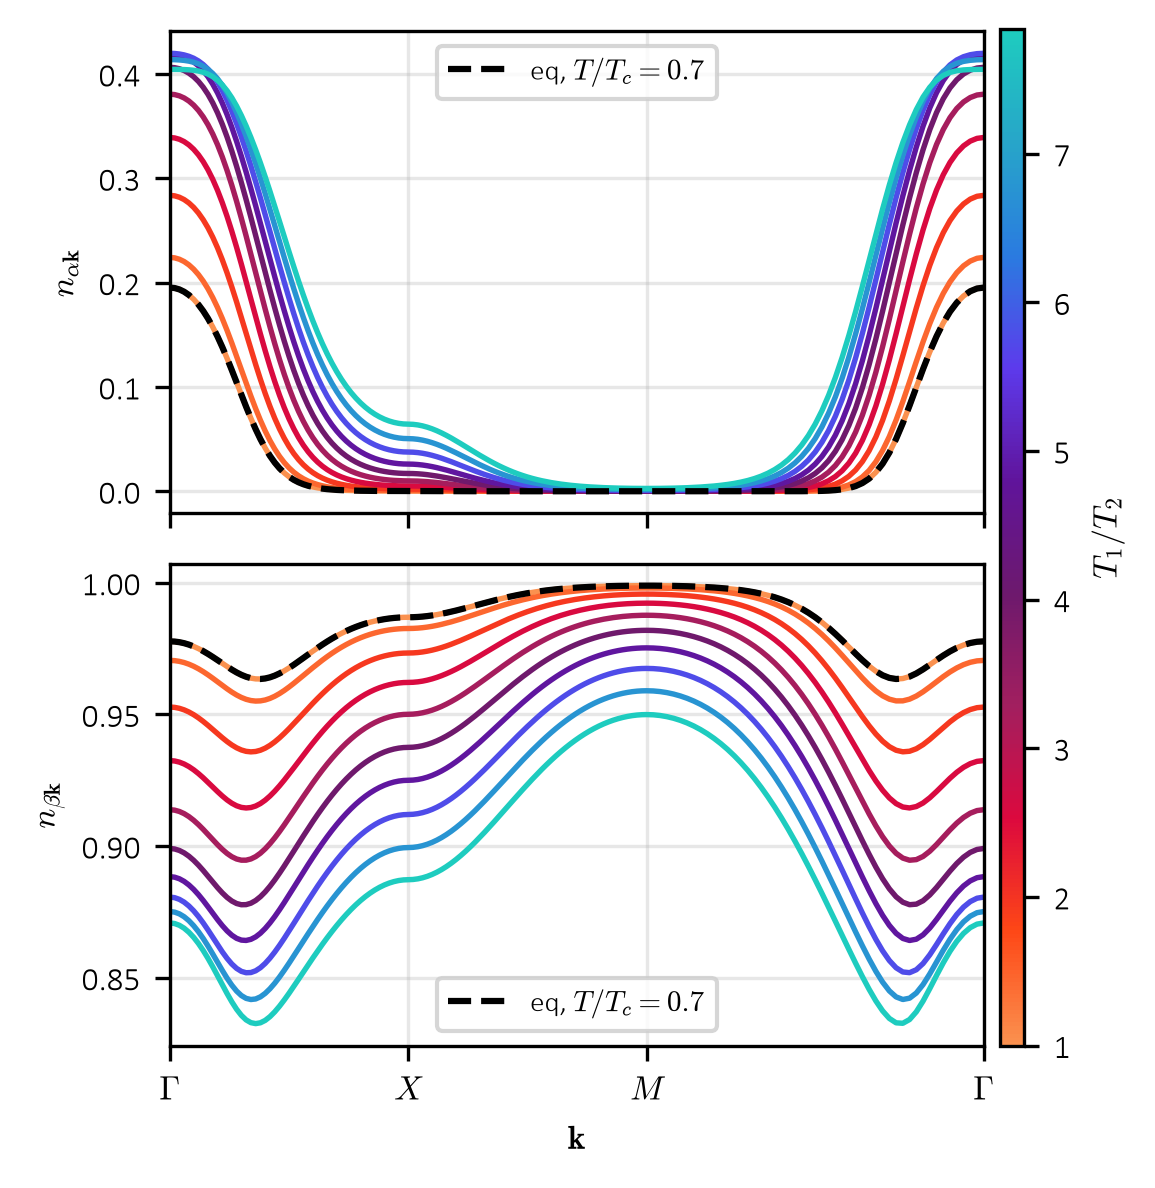

In [42]:
plot_nalpha_beta(naa, nba, nea, neb, r, ks, kt, kl,cfg, OUT=OUT, name="nalpha_beta_test", save=True, overwrite=True)

In [50]:
def plot_nalpha_beta_bz(nfa, r, q0, config, OUT=None, name="nalpha_beta_bz", save=False, overwrite=False):
    if q0 < 0 or q0 >= r.size:
        raise IndexError("q0 is outside the ratio sweep")

    nf = nfa[q0]
    nk1 = nf.shape[-1]

    ke = np.linspace(-1.0, 1.0, nk1 + 1)

    h = 0.62
    fig, ax = plt.subplots(1, 2, figsize=(3.47412, h * 3.47412), sharex=True, sharey=True)

    im0 = ax[0].pcolormesh(ke, ke, nf[0].T, shading="flat", cmap=cmaps.lipari, vmin=0.0, vmax=1.0)
    im0.set_edgecolor("face")

    im1 = ax[1].pcolormesh(ke, ke, nf[1].T, shading="flat", cmap=cmaps.lipari, vmin=0.0, vmax=1.0)
    im1.set_edgecolor("face")

    ax[0].text(0.05, 0.93, r"$n_{\alpha\mathbf{k}}$", transform=ax[0].transAxes,
               color="white", ha="left", va="top")

    ax[1].text(0.05, 0.93, r"$n_{\beta\mathbf{k}}$", transform=ax[1].transAxes,
               color="white", ha="left", va="top")

    ax[1].text(0.95, 0.93, rf"$T_1/T_2={r[q0]:.2f}$", transform=ax[1].transAxes,
               color="white", ha="right", va="top")

    for a in ax:
        a.set_xlim(ke[0], ke[-1])
        a.set_ylim(ke[0], ke[-1])
        a.set_aspect("equal")
        a.set_xlabel(r"$k_x/\pi$")

    ax[0].set_ylabel(r"$k_y/\pi$")

    cax = inset_axes(ax[1], width="3%", height="100%", loc="lower left",
                     bbox_to_anchor=(1.02, 0, 1, 1), bbox_transform=ax[1].transAxes, borderpad=0)

    cbar = fig.colorbar(im1, cax=cax)
    cbar.set_label(r"$n_{\lambda\mathbf{k}}$", rotation=90, labelpad=5)

    plt.tight_layout()

    if save:
        if OUT is None:
            raise ValueError("OUT must be provided when save=True")

        OUT = Path(OUT)
        OUT.mkdir(parents=True, exist_ok=True)

        plot_file = OUT / f"{name}.pdf"
        pars_file = OUT / f"{name}.yaml"

        if not overwrite and (plot_file.exists() or pars_file.exists()):
            raise FileExistsError(f"{name} already exists in {OUT}")

        meta = {
            "figure": plot_file.name,
            "plot": {
                "q0": int(q0),
                "ratio": float(r[q0]),
            },
            "simulation": config,
        }

        txt = yaml.safe_dump(meta, sort_keys=False)
        fig.savefig(plot_file, bbox_inches="tight")
        pars_file.write_text(txt, encoding="utf-8")

        print("Saved:", plot_file)
        print("Saved:", pars_file)

    plt.show()

/tmp/ipykernel_11206/795335668.py:42: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


Saved: /home/kzeleznikar/IJS-F1/Koda/EI_baths/nalpha_beta_bz_q3.pdf
Saved: /home/kzeleznikar/IJS-F1/Koda/EI_baths/nalpha_beta_bz_q3.yaml


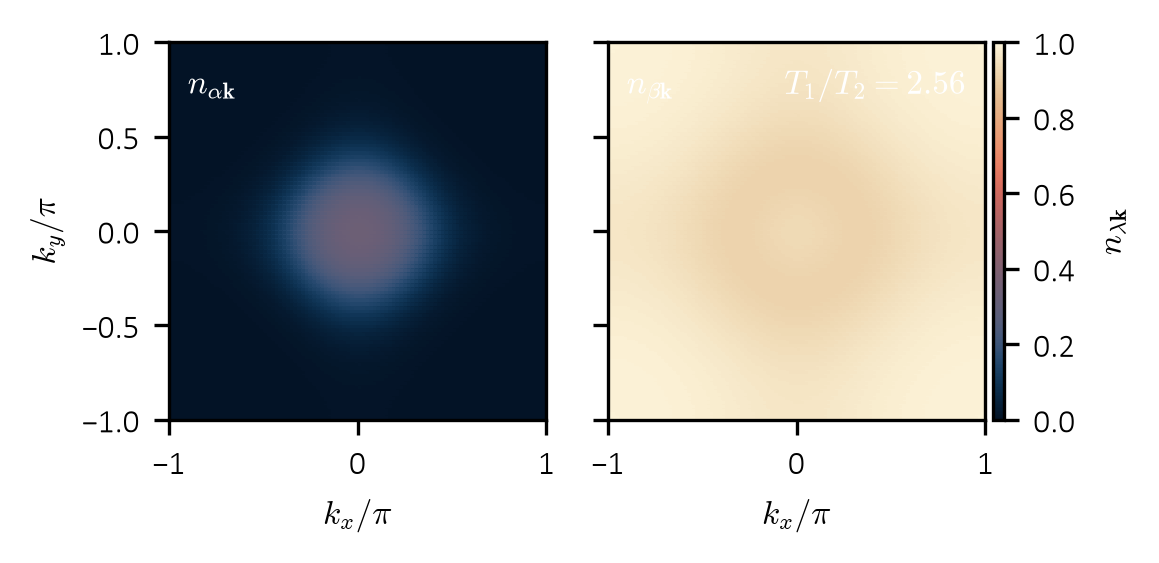

In [57]:
q0 = 3

plot_nalpha_beta_bz(nfa, r, q0, cfg, OUT=OUT, name="nalpha_beta_bz_q3", save=True, overwrite=True)

In [ ]:
x0 = 0.7
r = np.arange(1.0, 3.0, 0.2) ** 2
x1a = x0 * np.sqrt(r)
x2a = x0 / np.sqrt(r)

t0 = x0 * tc

bd_dense = eu.tb_2d(cfg["nk_sparse"], **cfg["tb_2d"])

se = eu.solve_eq(bd_dense, p, t=t0, d=max(abs(s0.d), 1.0e-4), m=s0.m, mix=(0.15, 0.15), tol=1.0e-9, nmax=20000, chk=20, prog=True)

nk1 = int(round(np.sqrt(se.n.shape[1])))

c = nk1 // 2
q = np.arange(c + 1)

i1 = c - q
j1 = np.full_like(q, c)

i2 = np.zeros(c, dtype=int)
j2 = c - np.arange(1, c + 1)

i3 = np.arange(1, c + 1)
j3 = np.arange(1, c + 1)

ii = np.concatenate((i1, i2, i3))
jj = np.concatenate((j1, j2, j3))

s1 = np.linspace(0.0, np.pi, c + 1)
s2 = np.linspace(np.pi, 2.0 * np.pi, c + 1)[1:]
s3 = np.linspace(
    2.0 * np.pi,
    (2.0 + np.sqrt(2.0)) * np.pi,
    c + 1,
)[1:]

ks = np.concatenate((s1, s2, s3))

kt = [
    0.0,
    np.pi,
    2.0 * np.pi,
    (2.0 + np.sqrt(2.0)) * np.pi,
]

kl = [
    r"$\Gamma$",
    r"$X$",
    r"$M$",
    r"$\Gamma$",
]


def path(n):
    n = np.asarray(n)
    na = n[0].reshape(nk1, nk1)[ii, jj]
    nb = n[1].reshape(nk1, nk1)[ii, jj]
    return na, nb


nea, neb = path(se.n)

kaa = 0.3
kab = 0.6
kbb = 0.3
wc = np.inf

# Output arrays
naa = np.empty((x2a.size, ks.size))
nba = np.empty_like(naa)
da1 = np.empty(x2a.size)
era = np.empty(x2a.size)
oka = np.empty(x2a.size, dtype=bool)

eaa = np.empty_like(naa)
eba = np.empty_like(naa)
ua = np.empty_like(naa)
va = np.empty_like(naa)

eah = np.empty_like(naa)
ebh = np.empty_like(naa)

def path1(z):
    z = np.asarray(z).reshape(nk1, nk1)
    return z[ii, jj]


n = se.n.copy()
d = se.d
m = se.m

bar = tqdm(range(r.size), desc="Ratio sweep")

for q in bar:
    x1 = x1a[q]
    x2 = x2a[q]

    t1 = x1 * tc
    t2 = x2 * tc
    
    bs = (
        ej.gam_db(
            t1,
            kap=(kaa, kab, kbb),
            wc=wc,
            mu=mu_B,
            name="bath 1",
            rate=ej.rate_product,
        ),
        ej.gam_db(
            t2,
            kap=(kaa, kab, kbb),
            wc=wc,
            mu=mu_B,
            name="bath 2",
            rate=ej.rate_product,
        ),
    )

    sp = ej.solve_open(
        bd_dense,
        p,
        n,
        bs,
        d=d,
        m=m,
        dt=0.8,
        td=0.3,
        tm=0.3,
        tol=1.0e-5,
        nmax=20000,
        chk=20,
        prog=False,
    )

    naa[q], nba[q] = path(sp.n)
    da1[q] = abs(sp.d)
    era[q] = sp.err
    oka[q] = sp.ok
    
    eaa[q], eba[q] = path(sp.st.e)
    ua[q] = path1(sp.st.u)
    va[q] = path1(sp.st.v)

    eah[q] = path1(sp.st.eah)
    ebh[q] = path1(sp.st.ebh)

    n = sp.n.copy()
    d = sp.d
    m = sp.m

    bar.set_postfix(
        r=f"{r[q]:.2f}",
        t1=f"{x1:.2f}",
        t2=f"{x2:.2f}",
        d=f"{abs(sp.d):.3e}",
        err=f"{sp.err:.2e}",
    )

print("All converged:", np.all(oka))
print("Largest error:", np.max(era))

In [ ]:
print("ks: ", ks.shape)
print("eaa:", eaa.shape)
print("eba:", eba.shape)
print("ua: ", ua.shape)
print("va: ", va.shape)

In [ ]:
ra = r

norm = Normalize(vmin=ra.min(), vmax=ra.max())
cm = bgr_custom
sm = ScalarMappable(norm=norm, cmap=cm)
sm.set_array([])

h = 1.15
fig, ax = plt.subplots(
    2,
    1,
    figsize=(3.47412, h * 3.47412),
    sharex=True,
)

for q in tqdm(range(x2a.size), desc="Plotting"):
    cl = cm(norm(ra[q]))

    ax[0].plot(
        ks,
        naa[q],
        color=cl,
        linewidth=1.3,
    )

    ax[1].plot(
        ks,
        nba[q],
        color=cl,
        linewidth=1.3,
    )

ax[0].plot(
    ks,
    nea,
    color="black",
    linestyle="--",
    linewidth=1.5,
    label=rf"eq, $T/T_c={x0:.1f}$",
)

ax[1].plot(
    ks,
    neb,
    color="black",
    linestyle="--",
    linewidth=1.5,
    label=rf"eq, $T/T_c={x0:.1f}$",
)

ax[0].set_ylabel(r"$n_{\alpha\mathbf{k}}$")
ax[1].set_ylabel(r"$n_{\beta\mathbf{k}}$")
ax[1].set_xlabel(r"$\mathbf{k}$")

for a in ax:
    a.set_xlim(ks[0], ks[-1])
    a.set_xticks(kt)
    a.set_xticklabels(kl)
    a.grid(alpha=0.3)
    a.legend(loc="best", fontsize=7)


cax = inset_axes(
    ax[1],
    width="3%",  # Makes the colorbar thin
    height="220%",  # Adjusts height to span both subplots
    loc="lower left",
    bbox_to_anchor=(1.02, 0, 1, 1),
    bbox_transform=ax[1].transAxes,
    borderpad=0,
)

cbar = fig.colorbar(sm, cax=cax)
cbar.set_label(r"$T_1/T_2$", rotation=90, labelpad=5)

# plt.savefig(OUT+"nalpha_beta_b2.pdf", bbox_inches="tight")
plt.show()

In [ ]:
q0 = 3

nf = np.asarray(sp.n).reshape(2, nk1, nk1)

# Cell edges over the full Brillouin zone
ke = np.linspace(-1.0, 1.0, nk1 + 1)

h = 0.62
fig, ax = plt.subplots(
    1,
    2,
    figsize=(3.47412, h * 3.47412),
    sharex=True,
    sharey=True,
)

im0 = ax[0].pcolormesh(
    ke,
    ke,
    nf[0].T,
    shading="flat",
    cmap=cmaps.lipari,
    vmin=0.0,
    vmax=1.0,
)
im0.set_edgecolor("face")

im1 = ax[1].pcolormesh(
    ke,
    ke,
    nf[1].T,
    shading="flat",
    cmap=cmaps.lipari,
    vmin=0.0,
    vmax=1.0,
)
im1.set_edgecolor("face")

ax[0].text(
    0.05,
    0.93,
    r"$n_{\alpha\mathbf{k}}$",
    transform=ax[0].transAxes,
    color="white",
    ha="left",
    va="top",
)

ax[1].text(
    0.05,
    0.93,
    r"$n_{\beta\mathbf{k}}$",
    transform=ax[1].transAxes,
    color="white",
    ha="left",
    va="top",
)

ax[1].text(
    0.95,
    0.93,
    rf"$T_1/T_2={r[q0]:.2f}$",
    transform=ax[1].transAxes,
    color="white",
    ha="right",
    va="top",
)

for a in ax:
    a.set_xlim(ke[0], ke[-1])
    a.set_ylim(ke[0], ke[-1])
    a.set_aspect("equal")
    a.set_xlabel(r"$k_x/\pi$")

ax[0].set_ylabel(r"$k_y/\pi$")

cax = inset_axes(
    ax[1],
    width="3%",  # Makes the colorbar thin
    height="100%",  # Adjusts height to span both subplots
    loc="lower left",
    bbox_to_anchor=(1.02, 0, 1, 1),
    bbox_transform=ax[1].transAxes,
    borderpad=0,
)

cbar = plt.colorbar(
    im1,
    cax=cax,
    fraction=0.046,
    pad=0.04,
)
cbar.set_label(
    r"$n_{\lambda\mathbf{k}}$",
    rotation=90,
    labelpad=5,
)

plt.tight_layout()
plt.show()

In [ ]:
norm = Normalize(vmin=ra.min(), vmax=ra.max())
cm = bgr_custom
sm = ScalarMappable(norm=norm, cmap=cm)
sm.set_array([])

h = 1.15
fig, ax = plt.subplots(
    2,
    1,
    figsize=(3.47412, h * 3.47412),
    sharex=True,
)

for q in tqdm(range(ra.size), desc="Plotting"):
    cl = cm(norm(ra[q]))

    ax[0].plot(ks, eaa[q], color=cl, linestyle="-", linewidth=1.2)

    ax[0].plot(ks, eba[q], color=cl, linestyle="--", linewidth=1.2,)

    ax[0].plot(ks, eah[0], color="k", linestyle="-", linewidth=0.5,)

    ax[0].plot(
        ks,
        ebh[0],
        color="k",
        linestyle="-",
        linewidth=0.5,
    )
    
    ax[1].plot(
        ks,
        ua[q],
        color=cl,
        linestyle="-",
        linewidth=1.2,
    )

    ax[1].plot(
        ks,
        va[q],
        color=cl,
        linestyle="--",
        linewidth=1.2,
    )

    # ax[1].plot(
    #     ks,
    #     va[q] ** 2 + ua[q] ** 2,
    #     color=cl,
    #     linestyle="--",
    #     linewidth=1.2,
    # )

# Line-style legends
ax[0].plot(
    [],
    [],
    color="black",
    linestyle="-",
    label=r"$E_{\alpha\mathbf{k}}$",
)

ax[0].plot(
    [],
    [],
    color="black",
    linestyle="--",
    label=r"$E_{\beta\mathbf{k}}$",
)

ax[1].plot(
    [],
    [],
    color="black",
    linestyle="-",
    label=r"$u_{\mathbf{k}}$",
)

ax[1].plot(
    [],
    [],
    color="black",
    linestyle="--",
    label=r"$v_{\mathbf{k}}$",
)

ax[0].set_ylabel(r"$E_{\lambda\mathbf{k}}/|t_a|$")
ax[1].set_ylabel(r"$u_{\mathbf{k}},\,v_{\mathbf{k}}$")
ax[1].set_xlabel(r"$\mathbf{k}$")

for a in ax:
    a.set_xlim(ks[0], ks[-1])
    a.set_xticks(kt)
    a.set_xticklabels(kl)
    a.grid(alpha=0.3)
    a.legend(loc="best", ncol=2, fontsize=8)

cax = inset_axes(
    ax[1],
    width="3%",  # Makes the colorbar thin
    height="220%",  # Adjusts height to span both subplots
    loc="lower left",
    bbox_to_anchor=(1.02, 0, 1, 1),
    bbox_transform=ax[1].transAxes,
    borderpad=0,
)

cbar = fig.colorbar(sm, cax=cax)
cbar.set_label(r"$T_1/T_2$", rotation=90, labelpad=5)

plt.show()

In [ ]:
nk = 100

bd = eu.tb_2d(
    nk=nk,
    gap=1.0,
    ta=1.0,
    tb=-0.3,
)


va = np.linspace(0.0, 8.0, 6)
t = 0.1

# Momentum window around Gamma
kw = 1 * np.pi

nk1 = int(round(np.sqrt(bd.ea.size)))
c = nk1 // 2

ka = 2.0 * np.pi * (np.arange(nk1) - c) / nk1
im = np.abs(ka) <= kw
kx = ka[im]

eaa = np.empty((va.size, kx.size))
eba = np.empty_like(eaa)
da = np.empty(va.size)
mua = np.empty(va.size)

# Initial seed
d = max(abs(s0.d), 1.0e-3)
m = s0.m

bar = tqdm(range(va.size), desc="V sweep")

for q in bar:
    v0 = va[q]

    pq = eu.MFPars(
        v=float(v0),
        n=p.n,
        uh=None,
    )

    sq = eu.solve_eq(
        bd,
        pq,
        t=t,
        d=max(abs(d), 1.0e-3),
        m=m,
        mix=(0.15, 0.15),
        tol=1.0e-7,
        nmax=20000,
        chk=20,
        prog=False,
    )

    st = ej.mf_state(
        bd,
        pq,
        sq.d,
        sq.m,
    )

    ea = np.asarray(st.e[0]).reshape(nk1, nk1)
    eb = np.asarray(st.e[1]).reshape(nk1, nk1)

    # ky = 0 and energies relative to mu
    # eaa[q] = ea[im, c] - sq.mu
    eaa[q] = ea[im, c] - sq.mu
    # eba[q] = eb[im, c] - sq.mu
    eba[q] = eb[im, c] - sq.mu

    da[q] = abs(sq.d)
    mua[q] = sq.mu

    d = sq.d
    m = sq.m

    bar.set_postfix(
        v=f"{v0:.2f}",
        d=f"{abs(sq.d):.3e}",
        mu=f"{sq.mu:.3f}",
    )

In [ ]:
norm = Normalize(vmin=va.min(), vmax=va.max())
cm = bgr_custom
sm = ScalarMappable(norm=norm, cmap=cm)
sm.set_array([])

h = 0.75
fig, ax = plt.subplots(
    figsize=(3.47412, h * 3.47412)
)

for q in tqdm(range(va.size), desc="Plotting"):
    cl = cm(norm(va[q]))

    ax.plot(
        kx / np.pi,
        eaa[q],
        color=cl,
        linestyle="-",
        linewidth=1.3,
    )

    ax.plot(
        kx / np.pi,
        eba[q],
        color=cl,
        linestyle="--",
        linewidth=1.3,
    )

ax.plot(
    [],
    [],
    color="black",
    linestyle="-",
    label=r"$E_{\alpha}(k_x)-\mu$",
)

ax.plot(
    [],
    [],
    color="black",
    linestyle="--",
    label=r"$E_{\beta}(k_x)-\mu$",
)

ax.axhline(
    0.0,
    color="black",
    linewidth=0.8,
    alpha=0.5,
)

ax.set_xlim(kx[0] / np.pi, kx[-1] / np.pi)
ax.set_xlabel(r"$k_x/\pi$, $k_y=0$")
ax.set_ylabel(r"$(E_{\lambda\mathbf{k}}-\mu)/|t_a|$")

ax.grid(alpha=0.3)
ax.legend(loc="best")

cbar = fig.colorbar(sm, ax=ax)
cbar.set_label(r"$V/|t_a|$", rotation=90, labelpad=5)

plt.tight_layout()
plt.show()